# Corr_2PCF: Isotropic and Anisotropic Two-Point Statistics

This notebook shows how PyHermes measures the two-point correlation function from `ConvolsData`. The first half focuses on the isotropic `s`-mode, while the second half moves to anisotropic `(s, mu)` and `(rp, pi)` measurements, including explicit real-space versus redshift-space comparisons.

## Core idea

PyHermes turns pair counting into windowed field products. Data and random terms such as `dd`, `dr`, `rd`, and `rr` are combined into `xi`, while the pair window determines which separation or angular geometry is being measured.


In [1]:
from pyhermes.theory.corr2pcf import Corr_2PCF
from pyhermes.param.parambase import read_param
from pyhermes.io import WindowFunc, ConvolsData, Corr2PCFData
from pyhermes.utils.plot import plot_corr2pcf_2d
import matplotlib.pyplot as plt
import numpy as np
from numba import njit
import copy

from pathlib import Path
import os
os.chdir(Path.cwd().resolve().parent)
print(f"Working directory: {Path.cwd()}")

Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


## 1. Isotropic 2PCF: `xi(s)`

This section uses a one-dimensional separation grid. The most important ingredients are:

- the input data field and its matching random field
- the pair window, usually a shell-like window in separation
- the sampling grid in `s`
- the requested products, such as `dd`, `dr`, `rd`, `rr`, or directly `xi`


### Command-line entry point

This is the standard production path: run the official driver script from a YAML config and save the result to disk.


In [2]:
! mpirun -np 4 python ./scripts/run_2pcf.py ./configs/param_2pcf.yaml

16:12:08 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf.yaml'
16:12:08 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
16:12:08 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
16:12:08 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
16:12:08 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
16:12:08 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.pair_window'.
16:12:08 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
16:12:08 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.products' from 'xi' to '['dd', 'dr', 'rd', 'xi']'
16:12:08 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' fro

### Inspect the saved output

The next cell reloads the saved result, inspects its stored pair products, and reconstructs `xi` explicitly. This is a good sanity check on what the high-level task has computed.


16:12:39 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> ./output/quijote8000_snap004_2pcf.pkl <---
16:12:39 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 31, Min = 0, Max = 150
16:12:39 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['dd', 'dr', 'rd', 'delta_dd', 'rr', 'xi']


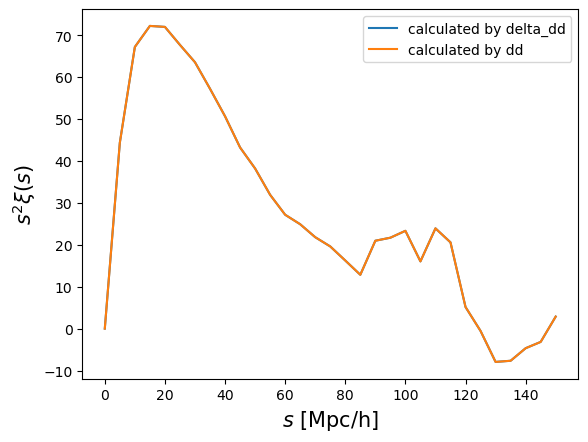

In [3]:
corr2pcf = Corr2PCFData(data_path='./output/quijote8000_snap004_2pcf.pkl')
s = corr2pcf.s
dd, dr, rd, rr = corr2pcf.dd, corr2pcf.dr, corr2pcf.rd, corr2pcf.rr
xi = (dd - dr - rd + rr) / rr

plt.plot(s, corr2pcf.xi*s**2, label='calculated by delta_dd')
plt.plot(s, xi*s**2, label='calculated by dd')
plt.xlabel(r'$s$ [Mpc/h]', fontsize=15)
plt.ylabel(r'$s^2\xi(s)$', fontsize=15)
plt.legend()
plt.show()

### Config-driven Python API

This version keeps the config file as the main specification, but returns the result directly in the notebook for interactive exploration.


In [4]:
corr2pcf_params = read_param('./configs/param_2pcf.yaml')
task = Corr_2PCF(param_task=corr2pcf_params)
task.products = 'xi'
task.threads = 8
corr2pcf = task.run(save_result=False)

16:12:39 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf.yaml'
16:12:39 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
16:12:39 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
16:12:39 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
16:12:39 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
16:12:39 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.pair_window'.
16:12:39 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
16:12:39 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.products' from 'xi' to '['dd', 'dr', 'rd', 'xi']'
16:12:39 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' fro

### Task object overrides

Here the task is assembled from a mix of paths, loaded field objects, and custom windows. This is the most practical level when you want to compare different smoothing choices without rebuilding every input from scratch.


In [5]:
D = ConvolsData(data_path='./output/quijote8000_snap004_sfc.pkl', threads=8)
R = ConvolsData(data_path='./output/random_sfc.pkl', threads=8)
win_params = {"type": "sphere", "len_args": {"R": 20}}
win_tophat20 = WindowFunc(win_params, D.convols_info, threads=8)

task = Corr_2PCF()
task.convols_data1 = './output/quijote8000_snap004_sfc.pkl'
task.convols_data2 = D
task.random1 = 'uniform'
task.random2 = R
task.window1 = win_params
task.window2 = win_tophat20
task.sampling['s'] = np.linspace(0, 150, 26)
task.products = "xi"
task.threads = 8
corr2pcf_sph20 = task.run(save_result=False)

16:12:48 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote8000_snap004_sfc.pkl <---
16:12:49 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -3.215e-06, Max = 1.343e-05, Mean = 5.96e-08, Sum = 1
16:12:49 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/random_sfc.pkl <---
16:12:49 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -2.192e-07, Max = 9.48e-07, Mean = 5.96e-08, Sum = 1
16:12:49 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
16:12:49 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Corr_2PCF runtime configuration: running on 1 MPI ranks with 8 threads per rank
16:12:49 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Preparing Corr_2PCF input fields ...
16:12:49 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Sampling: s: n=26, min=0.0, max=150.0, source=explicit array, threads=8
16:12:49 - INFO - pyhermes.pi

### Advanced: customize the pair window

The next three cells move beyond the default shell window. They define a custom cosine-based pair window and a custom mapping from the sampled separation to the window parameters. This is the right level if you want to prototype new estimators while still using the high-level `Corr_2PCF` task.


In [6]:
@njit
def window_function_cosine_numba(ki, kj, kk, R):
    k = np.sqrt(ki**2 + kj**2 + kk**2)
    result = np.cos(2 * np.pi * k * R)
    return result
    
def my_mapping_s_to_R(sample, pair_window):
    params = copy.deepcopy(pair_window)
    params["len_args"]["R"] = sample['s']
    return params

pair_win_params = {
    "type": "cosine", 
    "func": window_function_cosine_numba, 
    "len_args": ["R"],
    "mapping": my_mapping_s_to_R,
    "kernel_mode": "octant"
}

In [7]:
task = Corr_2PCF()
task.convols_data1 = './output/quijote8000_snap004_sfc.pkl'
task.convols_data2 = './output/quijote8000_snap004_sfc.pkl'
task.random1 = 'uniform'
task.random2 = 'uniform'
task.window1 = {"type": "gaussian", "len_args": {"R": 8}}
task.window2 = {"type": "gaussian", "len_args": {"R": 8}}
task.pair_window = pair_win_params
task.s = np.linspace(0, 150, 31)
task.threads = 8
corr2pcf_gauss8_cosine = task.run(save_result=False)

16:12:59 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
16:12:59 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Corr_2PCF runtime configuration: running on 1 MPI ranks with 8 threads per rank
16:12:59 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Preparing Corr_2PCF input fields ...
16:12:59 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Sampling: s: n=30, min=1.0, max=150.0, threads=8
16:12:59 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Products: requested=[xi] | computed=[delta_dd, rr] | derived=[xi]
16:12:59 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Pair window: type=cosine | mapping=my_mapping_s_to_R | kernel_mode=octant
16:12:59 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote8000_snap004_sfc.pkl <---
16:12:59 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -3.215e-06, Max = 1.343e-05, Mean = 5.96e-08, Sum = 1
16:12:59 - INFO - pyhermes.pipeline.pipeline:C

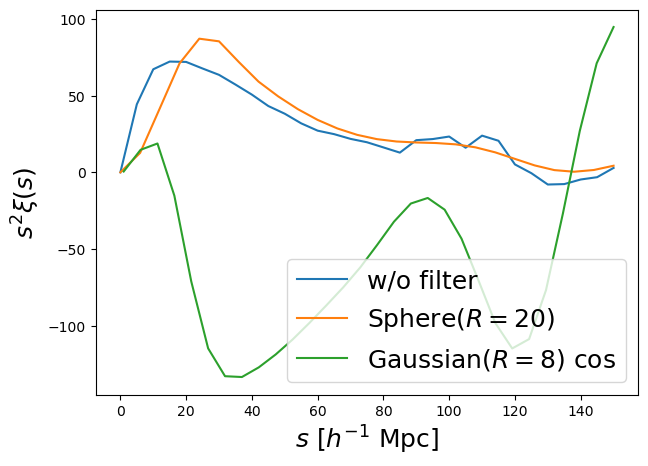

In [8]:
plt.figure(figsize=(7, 5))
plt.plot(corr2pcf.s, corr2pcf.xi*corr2pcf.s**2, label='w/o filter')
plt.plot(corr2pcf_sph20.s, corr2pcf_sph20.xi*corr2pcf_sph20.s**2, label=rf'Sphere($R=20$)')
plt.plot(corr2pcf_gauss8_cosine.s, corr2pcf_gauss8_cosine.xi*corr2pcf_gauss8_cosine.s**2, label=rf'Gaussian($R=8$) cos')

plt.xlabel(r'$s\ [h^{-1}\ \mathrm{Mpc}]$', fontsize='18')
plt.ylabel(r'$s^2 \xi(s)$', fontsize='18')
plt.legend(loc='best', fontsize='18')
plt.show()

### Low-level building blocks

The next cells reconstruct the 2PCF more manually:

- build a fluctuation field `delta = D - rho`
- smooth the field with an explicit window
- apply a shell pair window at each sampled radius
- average the resulting field product and divide by the random normalization

This is the clearest place to see the convolution-based principle behind the PyHermes 2PCF implementation.


In [9]:
win_params = {"type": "sphere", "len_args": {"R": 20}}
win_tophat20 = WindowFunc(win_params, D.convols_info, threads=8)

rho = 1 / D.V
deltaD = D - rho
deltaD_sph20 = deltaD @ win_tophat20
RR = rho ** 2

r_arr = np.linspace(0, 150, 31)
xi_arr = np.zeros_like(r_arr)
for i, r in enumerate(r_arr):
    win_params = {"type": "shell", "len_args": {"R": r}}
    pair_window_shell = WindowFunc(win_params, D.convols_info, threads=8)

    deltaDD = deltaD_sph20 @ pair_window_shell * deltaD_sph20
    
    xi_arr[i] = deltaDD.as_array().mean() / RR 

In [10]:
win_params = {"type": "gaussian", "len_args": {"R": 8}}
win_gauss8 = WindowFunc(win_params, D.convols_info, threads=8)
deltaD_gauss8 = deltaD @ win_gauss8

xi2_arr = np.zeros_like(r_arr)
for i, r in enumerate(r_arr):
    win_params = {"func": window_function_cosine_numba, "len_args": {"R": r}}
    pair_window_cos = WindowFunc(win_params, D.convols_info, threads=8)

    deltaDD = deltaD_gauss8 @ pair_window_cos * deltaD_gauss8
    
    xi2_arr[i] = deltaDD.as_array().mean() / RR

### Compare direct estimators

This plot lines up the stored task output with the manually reconstructed curves so that the effect of different smoothing choices is easy to read off.


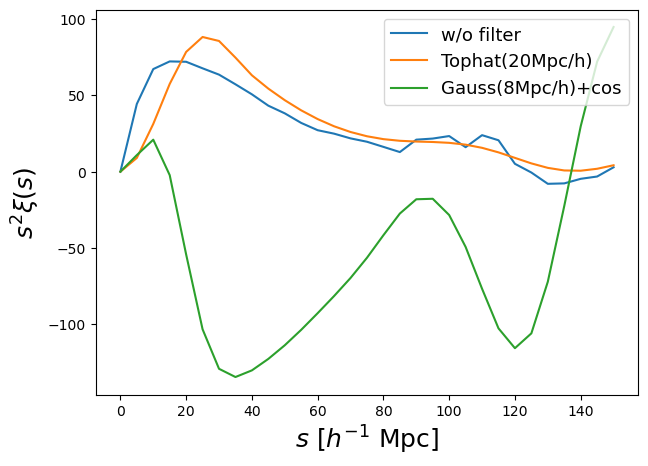

In [11]:
plt.figure(figsize=(7, 5))
plt.plot(corr2pcf.s, corr2pcf.xi*corr2pcf.s**2, label='w/o filter')
plt.plot(r_arr, xi_arr*r_arr**2, label=rf'Tophat(20Mpc/h)')
plt.plot(r_arr, xi2_arr*r_arr**2, label=rf'Gauss(8Mpc/h)+cos')

plt.xlabel(r'$s\ [h^{-1}\ \mathrm{Mpc}]$', fontsize='18')
plt.ylabel(r'$s^2 \xi(s)$', fontsize='18')
plt.legend(loc='best', fontsize='13')
plt.show()

## 2. Anisotropic 2PCF: `(s, mu)` and `(rp, pi)`

The remaining cells add line-of-sight geometry. This is the natural place to study redshift-space distortions: once the pair window knows about the line of sight, the output becomes a 2D correlation surface whose shape depends on both separation and viewing direction.


### Start from a smoke-test configuration

The first anisotropic run uses a compact `(s, mu)` grid so that the whole workflow stays light enough for notebook experimentation.


In [12]:
! mpirun -np 2 python ./scripts/run_2pcf.py ./configs/param_2pcf_smu_test.yaml

16:13:28 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf_smu_test.yaml'
16:13:28 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
16:13:28 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
16:13:28 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
16:13:28 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
16:13:28 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.pair_window'.
16:13:28 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
16:13:28 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' from '1' to '4'
16:13:28 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to '

### Inspect the first `(s, mu)` result

The next cell loads the stored output and plots it directly. After that, several small variations are applied to the same base config.


16:13:43 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> ./output/quijote8000_snap004_2pcf_smu_test.pkl <---
16:13:43 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 6, Min = 0, Max = 150
16:13:44 - INFO - pyhermes.io.base:Corr2PCFData - mu: Num = 6, Min = 0, Max = 1
16:13:44 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']


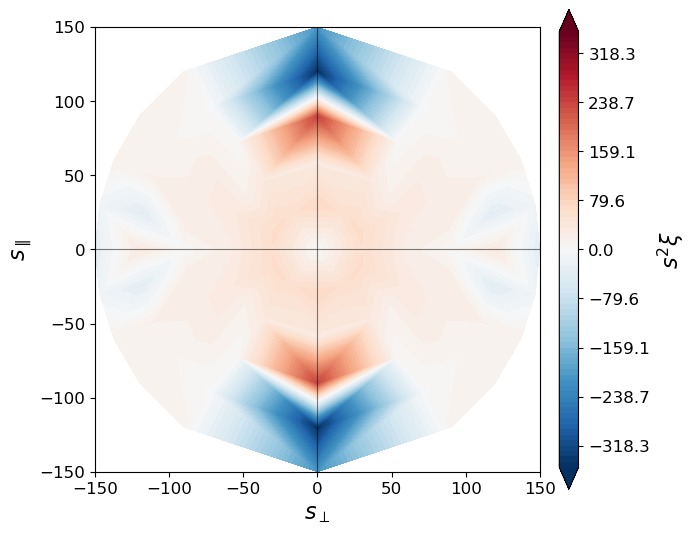

In [13]:
corr2pcf_smu = Corr2PCFData(data_path='./output/quijote8000_snap004_2pcf_smu_test.pkl')
plot_corr2pcf_2d(corr2pcf_smu)
plt.tight_layout()
plt.show()

### Vary the line of sight, smoothing, and coordinate choice

These cells reuse the same basic task and modify one ingredient at a time:

- change the line-of-sight direction
- smooth the two fields before measuring the pair statistic
- switch from `(s, mu)` sampling to `(rp, pi)` sampling

This is a compact way to see which parts of the 2D signal come from geometry and which come from field smoothing.


In [14]:
corr2pcf_params = read_param('./configs/param_2pcf_smu_test.yaml')
task = Corr_2PCF(param_task=corr2pcf_params)
task.pair_window['los_args'] = [1, 1, 1]
task.threads = 8
corr2pcf_smu_diag = task.run(save_result=False)

16:13:45 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf_smu_test.yaml'
16:13:45 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
16:13:45 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
16:13:45 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
16:13:45 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
16:13:45 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.pair_window'.
16:13:45 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
16:13:45 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' from '1' to '4'
16:13:45 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to '

In [15]:
corr2pcf_params = read_param('./configs/param_2pcf_smu_test.yaml')
task = Corr_2PCF(param_task=corr2pcf_params)
task.window1 = {"type": "sphere", "len_args": {"R": 5}}
task.window2 = {"type": "sphere", "len_args": {"R": 5}}
task.threads = 8
corr2pcf_smu_sph5 = task.run(save_result=False)

16:14:14 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf_smu_test.yaml'
16:14:14 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
16:14:14 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
16:14:14 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
16:14:14 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
16:14:14 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.pair_window'.
16:14:14 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
16:14:14 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' from '1' to '4'
16:14:14 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to '

In [16]:
corr2pcf_params = read_param('./configs/param_2pcf_smu_test.yaml')
task = Corr_2PCF(param_task=corr2pcf_params)
task.pair_window['mapping'] = 'rppi_to_RH'
task.sampling = {
    'rp': np.linspace(0, 150, 6),
    'pi': np.linspace(0, 150, 6)
}
task.threads = 8
corr2pcf_rppi = task.run(save_result=False)

16:14:25 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf_smu_test.yaml'
16:14:25 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
16:14:25 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
16:14:25 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
16:14:25 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
16:14:25 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.pair_window'.
16:14:25 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
16:14:25 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' from '1' to '4'
16:14:25 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to '

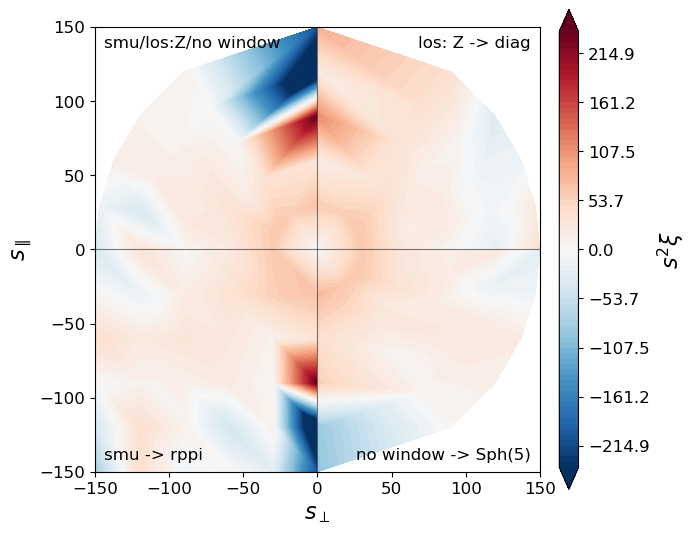

In [17]:
plot_corr2pcf_2d(
    quadrants={
        "upper_left": corr2pcf_smu,
        "upper_right": corr2pcf_smu_diag,
        "lower_left": corr2pcf_rppi,
        "lower_right": corr2pcf_smu_sph5,
    },
    quadrant_labels={
        "upper_left": "smu/los:Z/no window",
        "upper_right": "los: Z -> diag",
        "lower_left": "smu -> rppi",
        "lower_right": "no window -> Sph(5)",
    },
    coordinates=["smu", "smu", "rppi", "smu"],
    text_fontsize=12
)
plt.tight_layout()
plt.show()


### Advanced: custom anisotropic pair window

The next cells define a disk-like pair window in Fourier space and use it inside the high-level 2PCF task. This demonstrates how nonstandard pair geometries can still fit into the same PyHermes workflow.


In [18]:
from pyhermes.utils.special_functions import jn_numba

@njit
def window_function_mydisk_numba(ki, kj, kk, R, H):
    k_perp = np.sqrt(ki * ki + kj * kj)
    k_parallel = kk
    q_perp = 2.0 * np.pi * k_perp * R
    q_parallel = 2.0 * np.pi * k_parallel * H
    part_parallel = np.cos(q_parallel)
    if q_perp == 0.0:
        part_perp = 1.0
    else:
        part_perp = 2.0 * jn_numba(1, q_perp) / q_perp
    return part_perp * part_parallel

def my_mapping_smu_to_RH(sample, pair_window):
    params = copy.deepcopy(pair_window)
    s = sample['s']
    mu = sample['mu']
    params["len_args"]["R"] = s * np.sqrt(max(0.0, 1.0 - mu * mu))
    params["len_args"]["H"] = s * mu
    return params

mydisk_win_params = {
    "type": "my_disk", 
    "func": window_function_mydisk_numba, 
    "len_args": ['R', 'H'], 
    "mapping": my_mapping_smu_to_RH,
    "kernel_mode": "octant"
}

In [19]:
task = Corr_2PCF()
task.threads = 8
task.sampling['s'] = np.linspace(0, 150, 6)
task.sampling['mu'] = np.linspace(0, 1, 6)
task.convols_data1 = './output/quijote8000_snap004_sfc.pkl'
task.convols_data2 = './output/quijote8000_snap004_sfc.pkl'
task.random1 = './output/random_sfc.pkl'
task.random2 = './output/random_sfc.pkl'
task.pair_window = mydisk_win_params
corr2pcf_smu_disk_z = task.run(save_result=False)

16:14:36 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
16:14:36 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Corr_2PCF runtime configuration: running on 1 MPI ranks with 8 threads per rank
16:14:36 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Preparing Corr_2PCF input fields ...
16:14:36 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Sampling: s: n=6, min=0.0, max=150.0, source=explicit array | mu: n=6, min=0.0, max=1.0, source=explicit array, threads=8
16:14:36 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Products: requested=[xi] | computed=[delta_dd, rr] | derived=[xi]
16:14:36 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Pair window: type=my_disk | mapping=my_mapping_smu_to_RH | kernel_mode=octant
16:14:36 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote8000_snap004_sfc.pkl <---
16:14:37 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -3.215e-06, Max = 1.343

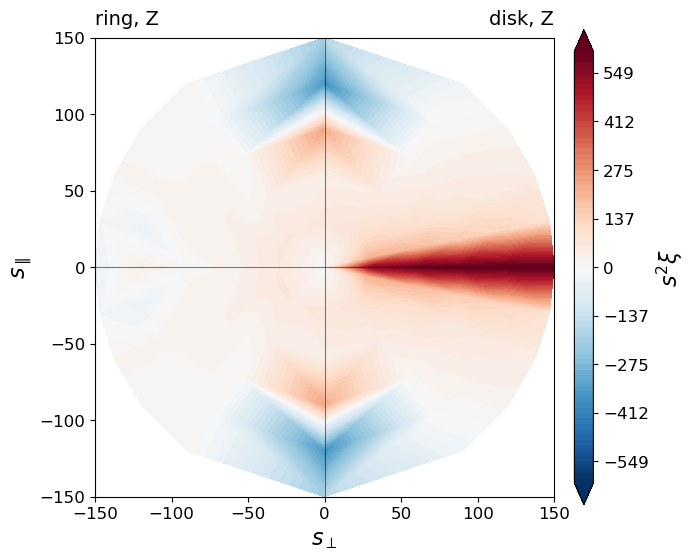

In [20]:
plot_corr2pcf_2d(corr2pcf_smu, corr2pcf_smu_disk_z, label1="ring, Z", label2="disk, Z")
plt.tight_layout()
plt.show()

### Advanced: pair window with an explicit line of sight

Here the pair window itself carries the line-of-sight direction as part of its parameters. This is useful when the geometry should be baked into the window definition rather than supplied separately by the task.


In [21]:
@njit
def window_function_mydisk_los_numba(ki, kj, kk, R, H, nx=0.0, ny=0.0, nz=1.0):
    norm = np.sqrt(nx * nx + ny * ny + nz * nz)
    if norm == 0.0:
        return np.nan
    nx = nx / norm
    ny = ny / norm
    nz = nz / norm

    k_parallel = ki * nx + kj * ny + kk * nz
    k2 = ki * ki + kj * kj + kk * kk
    k_perp2 = k2 - k_parallel * k_parallel

    if k_perp2 < 0.0:
        k_perp2 = 0.0

    k_perp = np.sqrt(k_perp2)
    q_perp = 2.0 * np.pi * k_perp * R
    q_parallel = 2.0 * np.pi * k_parallel * H

    part_parallel = np.cos(q_parallel)

    if q_perp == 0.0:
        part_perp = 1.0
    else:
        part_perp = 2.0 * jn_numba(1, q_perp) / q_perp
    return part_perp * part_parallel

def my_mapping_smu_to_RH_los(sample, pair_window):
    s = sample['s']
    mu = sample['mu']
    params = copy.deepcopy(pair_window)
    params["len_args"]["R"] = s * np.sqrt(max(0.0, 1.0 - mu * mu))
    params["len_args"]["H"] = s * mu
    return params

mydisk_diag_win_params = {
    "type": "my_disk", 
    "func": window_function_mydisk_los_numba, 
    "len_args": ['R', 'H'], 
    "los_args": {"nx": 1, "ny": 1, "nz": 1},
    "mapping": my_mapping_smu_to_RH_los,
    "kernel_mode": "full_rfft"
}

In [22]:
task = Corr_2PCF()
task.threads = 8
task.sampling['s'] = np.linspace(0, 150, 6)
task.sampling['mu'] = np.linspace(0, 1, 6)
task.convols_data1 = './output/quijote8000_snap004_sfc.pkl'
task.convols_data2 = './output/quijote8000_snap004_sfc.pkl'
task.random1 = 'uniform'
task.random2 = 'uniform'
task.pair_window = mydisk_diag_win_params
corr2pcf_smu_disk_diag = task.run(save_result=False)

16:14:55 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
16:14:55 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Corr_2PCF runtime configuration: running on 1 MPI ranks with 8 threads per rank
16:14:55 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Preparing Corr_2PCF input fields ...
16:14:55 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Sampling: s: n=6, min=0.0, max=150.0, source=explicit array | mu: n=6, min=0.0, max=1.0, source=explicit array, threads=8
16:14:55 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Products: requested=[xi] | computed=[delta_dd, rr] | derived=[xi]
16:14:55 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Pair window: type=my_disk | mapping=my_mapping_smu_to_RH_los | kernel_mode=full_rfft | los=(1.0, 1.0, 1.0)
16:14:55 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote8000_snap004_sfc.pkl <---
16:14:55 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), 

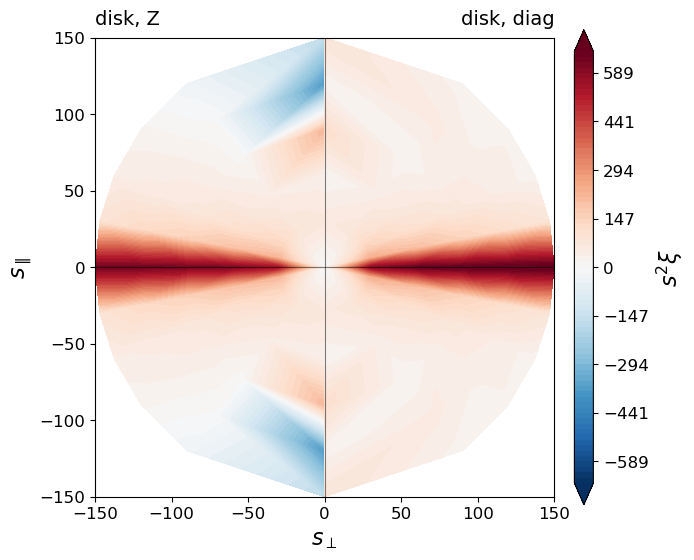

In [23]:
plot_corr2pcf_2d(corr2pcf_smu_disk_z, corr2pcf_smu_disk_diag, label1="disk, Z", label2="disk, diag")
plt.tight_layout()
plt.show()

### Compare saved production-style outputs

The last group of plots now shifts from smoke-test runs to saved real-space and redshift-space measurements. They highlight four practical questions:

- what changes when moving from real space to redshift space
- how the result changes when the line of sight is aligned with the box axis versus a diagonal direction
- how smoothing and random subtraction modify the anisotropic signal
- how different anisotropic pair-window families, such as disk and cylinder, compare in redshift space


In [24]:
# examples/scripts/run_2pcf.py & examples/configs/param_2pcf_smu_real.yaml
smu_z = Corr2PCFData(data_path='./output/quijote8000_snap004_2pcf_smu.pkl')
# examples/scripts/run_2pcf.py & examples/configs/param_2pcf_smu.yaml
rsd_smu_z = Corr2PCFData(data_path='./output/quijote8000_snap004_rsd_2pcf_smu.pkl')

16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> ./output/quijote8000_snap004_2pcf_smu.pkl <---
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 46, Min = 0, Max = 180
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - mu: Num = 51, Min = 0, Max = 1
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> ./output/quijote8000_snap004_rsd_2pcf_smu.pkl <---
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 46, Min = 0, Max = 180
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - mu: Num = 51, Min = 0, Max = 1
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']


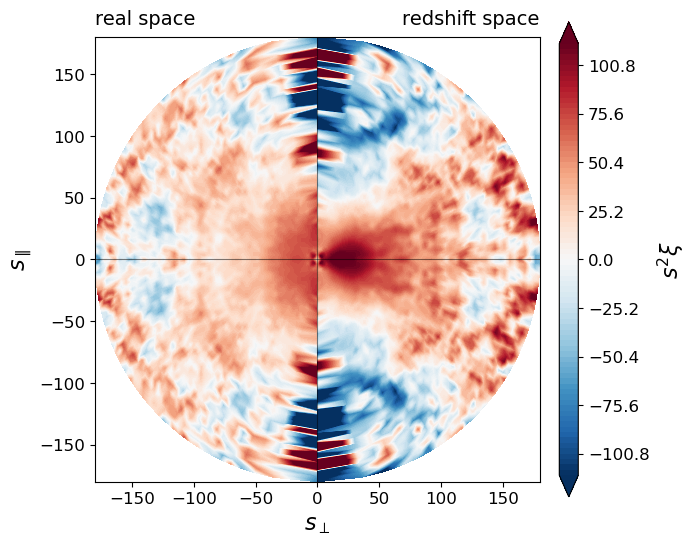

In [25]:
plot_corr2pcf_2d(smu_z, rsd_smu_z, label1="real space", label2="redshift space")
plt.tight_layout()
plt.show()

#### Inside redshift space: compare line-of-sight choice and smoothing

After the direct real-space versus redshift-space comparison, the next plot keeps only the redshift-space outputs and asks a finer question: how much of the 2D pattern comes from the chosen line of sight, and how much comes from the extra spherical smoothing?


In [26]:
# examples/scripts/run_2pcf.py & examples/configs/param_2pcf_smu_diag.yaml
rsd_smu_diag = Corr2PCFData(data_path='./output/quijote8000_snap004_rsd_2pcf_smu_diag.pkl')
# examples/scripts/run_2pcf.py & examples/configs/param_2pcf_smu_sph5.yaml
rsd_smu_sph5_z = Corr2PCFData(data_path='./output/quijote8000_snap004_rsd_2pcf_smu_sph5.pkl')
# examples/scripts/run_2pcf.py & examples/configs/param_2pcf_smu_sph5_diag.yaml
rsd_smu_sph5_diag = Corr2PCFData(data_path='./output/quijote8000_snap004_rsd_2pcf_smu_sph5_diag.pkl')

16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> ./output/quijote8000_snap004_rsd_2pcf_smu_diag.pkl <---
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 46, Min = 0, Max = 180
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - mu: Num = 51, Min = 0, Max = 1
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> ./output/quijote8000_snap004_rsd_2pcf_smu_sph5.pkl <---
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 46, Min = 0, Max = 180
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - mu: Num = 51, Min = 0, Max = 1
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> ./output/quijote8000_snap004_rsd_2pcf_smu_sph5_diag.pkl <---
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 46, Min = 0, Max = 180
1

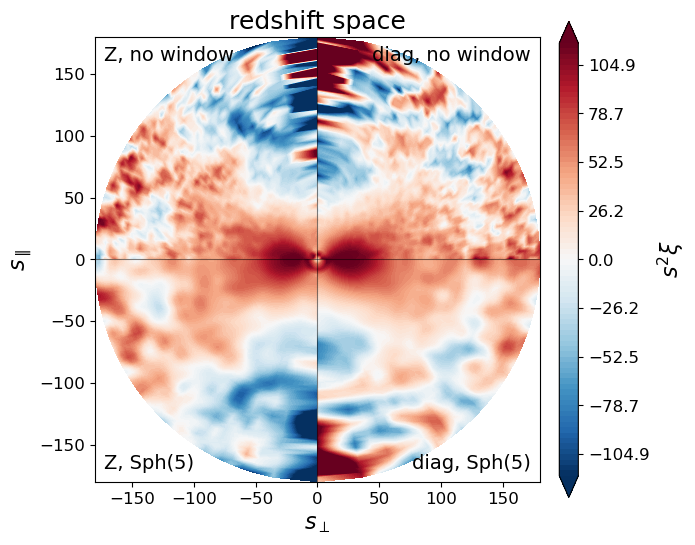

In [27]:
plot_corr2pcf_2d(
    quadrants={
        "upper_left": rsd_smu_z,
        "upper_right": rsd_smu_diag,
        "lower_left": rsd_smu_sph5_z,
        "lower_right": rsd_smu_sph5_diag,
    },
    quadrant_labels={
        "upper_left": "Z, no window",
        "upper_right": "diag, no window",
        "lower_left": "Z, Sph(5)",
        "lower_right": "diag, Sph(5)",
    },
    title="redshift space"
)
plt.tight_layout()
plt.show()


#### Compare `(s, mu)` and `(rp, pi)` views of the same redshift-space smoothed measurement


In [28]:
# examples/scripts/run_2pcf.py & examples/configs/param_2pcf_smu_sph5_with_random.yaml
rsd_smu_sph5_z_with_random = Corr2PCFData(data_path='./output/quijote8000_snap004_rsd_2pcf_smu_sph5_with_random.pkl')
# examples/scripts/run_2pcf.py & examples/configs/param_2pcf_rppi_sph5_with_random.yaml
rsd_rppi_sph5_z_with_random = Corr2PCFData(data_path='./output/quijote8000_snap004_rsd_2pcf_rppi_sph5_with_random.pkl')

16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> ./output/quijote8000_snap004_rsd_2pcf_smu_sph5_with_random.pkl <---
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 46, Min = 0, Max = 180
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - mu: Num = 51, Min = 0, Max = 1
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> ./output/quijote8000_snap004_rsd_2pcf_rppi_sph5_with_random.pkl <---
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - rp: Num = 46, Min = 0, Max = 180
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - pi: Num = 46, Min = 0, Max = 180
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']


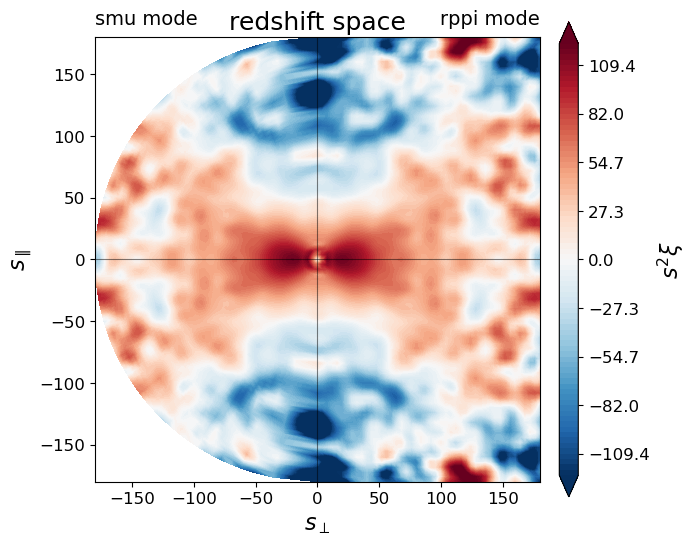

In [29]:
plot_corr2pcf_2d(rsd_smu_sph5_z_with_random, rsd_rppi_sph5_z_with_random, 
                 coordinates=['smu', 'rppi'], label1="smu mode", label2="rppi mode",
                 title="redshift space"
                 )
plt.tight_layout()
plt.show()

#### Compare alternative anisotropic window families in redshift space


In [30]:
# examples/scripts/run_2pcf.py & examples/configs/param_2pcf_smu_disk.yaml
rsd_smu_disk_z = Corr2PCFData(data_path='./output/quijote8000_snap004_rsd_2pcf_smu_disk.pkl')
# examples/scripts/run_2pcf.py & examples/configs/param_2pcf_smu_cylinder.yaml
rsd_smu_cyl_z = Corr2PCFData(data_path='./output/quijote8000_snap004_rsd_2pcf_smu_cylinder.pkl')

16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> ./output/quijote8000_snap004_rsd_2pcf_smu_disk.pkl <---
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 46, Min = 0, Max = 180
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - mu: Num = 51, Min = 0, Max = 1
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> ./output/quijote8000_snap004_rsd_2pcf_smu_cylinder.pkl <---
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 46, Min = 0, Max = 180
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - mu: Num = 51, Min = 0, Max = 1
16:15:16 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']


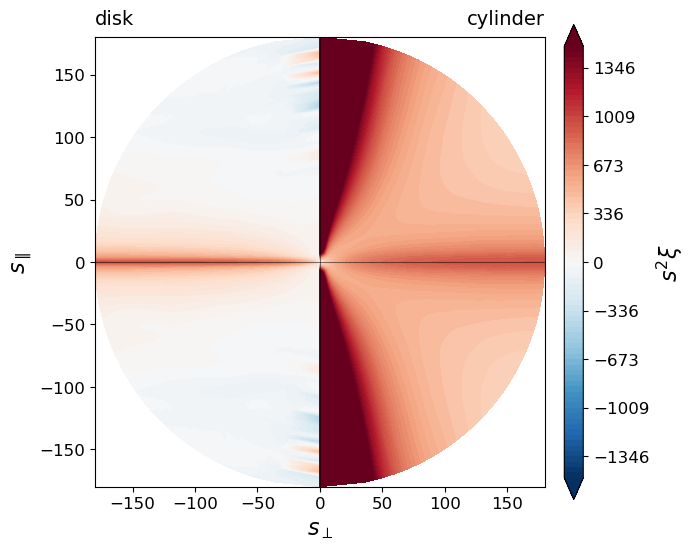

In [31]:
plot_corr2pcf_2d(rsd_smu_disk_z, rsd_smu_cyl_z, label1="disk", label2="cylinder")
plt.tight_layout()
plt.show()